In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## GROUP 13 Lab 05

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196

#  PROBLEM 2 : Analytical approach


## Analytical Approach

The numerical model represents the chain as a finite number of discrete masses connected by springs. In the **continuum limit**, where the number of masses becomes very large, the chain can be modeled as a smooth continuous curve \( y(x) \).

In this formulation, the equilibrium configuration is obtained by minimizing the total potential energy of the chain, which can be written as a functional:

$$
E[y] = \int L(y, y') \, dx
$$

where \( L(y, y') \) is the Lagrangian density and \( y' = \frac{dy}{dx} \).

For a hanging chain under gravity, the functional takes the form:

$$
E[y] = \int \rho g\, y \sqrt{1 + (y')^2} \, dx
$$

To minimize this energy, we apply the **Euler–Lagrange equation**:

$$
\frac{d}{dx}\left(\frac{\partial L}{\partial y'}\right) - \frac{\partial L}{\partial y} = 0
$$

Solving this equation yields the **catenary curve**:

$$
y = a \cosh\left(\frac{x}{a}\right)
$$

This represents the exact equilibrium shape of a hanging chain.

### Comparison

The numerical solution obtained from the discrete mass–spring model approaches this analytical solution as the number of masses increases, converging to the smooth catenary curve.

In [8]:
#code from previous solution
N = 20
m = 1.0
g = 9.8
k = 50.0
L0 = 1.0
def total_energy(y_middle):


    y = np.concatenate(([0], y_middle, [0]))

    E_gravity = 0
    E_spring = 0


    for j in range(len(y)):
        E_gravity += m * g * y[j]


    for j in range(len(y) - 1):
        dy = y[j+1] - y[j]
        length = np.sqrt(1 + dy**2)
        E_spring += 0.5 * k * (length - L0)**2

    return E_gravity + E_spring

initial_guess = np.zeros(N-2)
result = minimize(total_energy, initial_guess)
y_middle = result.x
y = np.concatenate(([0], y_middle, [0]))
x = np.arange(N)


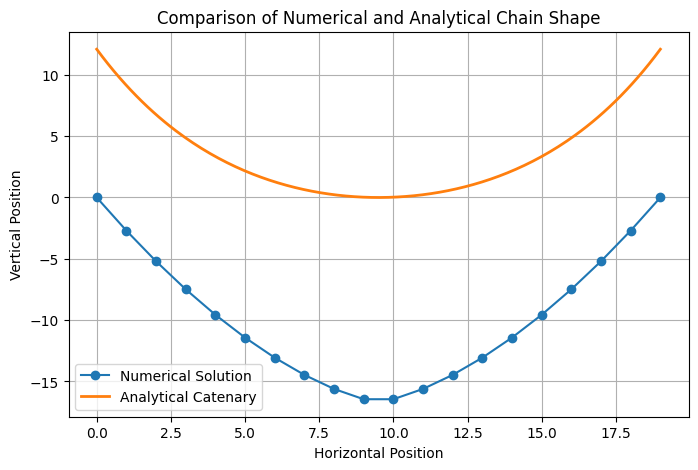

In [9]:
# Analytical catenary curve for comparison

a = 5   # parameter controlling curvature

x_cont = np.linspace(0, N-1, 200)


x_shift = x_cont - (N-1)/2

y_catenary = a * np.cosh(x_shift/a) - a

plt.figure(figsize=(8,5))

# numerical solution from mass-spring model
plt.plot(x, y, 'o-', label="Numerical Solution")

# analytical catenary curve
plt.plot(x_cont, y_catenary, label="Analytical Catenary", linewidth=2)

plt.xlabel("Horizontal Position")
plt.ylabel("Vertical Position")
plt.title("Comparison of Numerical and Analytical Chain Shape")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

### Numerical vs Analytical Results

In this lab, we studied the equilibrium shape of a chain under gravity using two approaches:

1. **Numerical Approach**  
   - The chain was modeled as discrete masses connected by springs.  
   - The equilibrium configuration was obtained by **minimizing the total energy** (gravitational + elastic).  
   - The resulting shape depends on parameters like spring constant, mass, and spacing.

2. **Analytical Approach (Continuum Limit)**  
   - By taking the limit of infinitely many masses, the system becomes continuous.  
   - Using the **calculus of variations**, the energy functional is minimized.  
   - This leads to the classical **catenary curve**, given by:
   $$
y = a \cosh\left(\frac{x}{a}\right)
$$


### Why Do We Observe Changes Between the Two Plots?

- In the **numerical model**, the chain is discrete (finite number of masses), so:
  - The curve appears slightly **piecewise or polygonal**.
  - Accuracy depends on the number of masses and spring stiffness.

- In the **analytical model**, the chain is continuous:
  - The curve is **perfectly smooth**.
  - It represents the ideal physical solution.

- As we **increase the number of masses** (refine the discretization):
  - The numerical result **converges** to the analytical catenary curve.
  - The differences between the two plots reduce.


### Key Observations

- The equilibrium shape is governed by **energy minimization**.
- Both approaches confirm that the natural shape of a hanging chain is a **catenary**, not a parabola.
- Discrete systems approximate continuous systems when the number of elements increases.
- Numerical methods are powerful for solving problems where analytical solutions are difficult or unavailable.
